In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import timm
import pickle

DATA_PATH = "D:/ML/RSNA2024"

c:\Users\Manuel\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Data Processing

In [3]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df = df.fillna("Normal/Mild")
df.set_index("study_id", inplace=True)
df.head(10)

,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,left_neural_foraminal_narrowing_l5_s1,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
study_id,,,,,,,,,,,,,,,,,,,,,
4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild
11340341,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild
11943292,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
13317052,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Severe,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate
22191399,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Moderate


In [4]:
pd.unique(df["spinal_canal_stenosis_l1_l2"])

array(['Normal/Mild', 'Moderate', 'Severe'], dtype=object)

In [5]:
dfCoord = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))
dfCoord.set_index("study_id", inplace=True)
dfCoord.head(20)

,series_id,instance_number,condition,level,x,y
study_id,,,,,,
4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182
4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434
4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602
4003253,1054713880,4,Right Neural Foraminal Narrowing,L4/L5,187.961759,251.839388
4003253,1054713880,4,Right Neural Foraminal Narrowing,L5/S1,198.240918,285.613767
4003253,1054713880,5,Right Neural Foraminal Narrowing,L3/L4,187.227533,210.722753
4003253,1054713880,6,Right Neural Foraminal Narrowing,L1/L2,194.569790,127.755258


In [6]:
dfCoord.describe()

,series_id,instance_number,x,y
count,4.869200e+04,48692.000000,48692.000000,48692.000000
mean,2.154461e+09,13.409677,238.237527,233.070212
std,1.244319e+09,56.585031,73.226429,92.480334
min,1.099600e+04,1.000000,4.058824,2.063098
25%,1.069855e+09,7.000000,179.068100,164.740474
50%,2.163803e+09,11.000000,234.836173,219.125160
75%,3.242314e+09,15.000000,282.732743,289.759563
max,4.294540e+09,5046.000000,686.190305,801.859719


In [7]:
allConditions = pd.unique(dfCoord["condition"])
allLevels = pd.unique(dfCoord["level"])
allLabels = np.array(df.columns)

labelMapping = {"Normal/Mild": 0, "Moderate":1, "Severe":2}

In [8]:
def getLabelVector(condition, studyId):
    condition = condition.lower().replace(" ","_")
    labelVec = np.zeros_like(allLabels)
    for l in allLevels:
        l = l.lower().replace("/","_")
        idx = np.argwhere(allLabels==f"{condition}_{l}")
        severity = df.loc[studyId][f"{condition}_{l}"]
        labelVec[idx[0][0]]=labelMapping[severity]
    return labelVec

getLabelVector("Spinal Canal Stenosis", 4646740)


array([0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0], dtype=object)

In [9]:
if os.path.exists(os.path.join(DATA_PATH,"./mappedLabels.pkl")):
    with open(os.path.join(DATA_PATH,"./mappedLabels.pkl"), "rb") as f:
        mappedLabels = pickle.load(f)
else:
    mappedLabels= {}

    for studyId in tqdm(dfCoord.index): 
        filteredDf = dfCoord.loc[studyId]
        uniqueSeries = pd.unique(filteredDf["series_id"])
        filteredDf.set_index("series_id", inplace=True)
        for series in uniqueSeries:
            filteredDfSeries = filteredDf.loc[series]
            if isinstance(filteredDfSeries, pd.Series):
                instance = filteredDfSeries["instance_number"]
                condition = filteredDfSeries["condition"]
                labelVec = getLabelVector(condition, studyId)
                mappedLabels[f"train_images/{studyId}/{series}/{instance}.dcm"] = labelVec
                continue
            else:
                uniqueInstances = pd.unique(filteredDfSeries["instance_number"])
            for instance in uniqueInstances:
                filteredDfInstance = filteredDfSeries[filteredDfSeries["instance_number"]==instance]
                uniqueConditions = pd.unique(filteredDfInstance["condition"])
                labelVec = np.zeros_like(allLabels)
                for condition in uniqueConditions:
                    labelVec += getLabelVector(condition, studyId)
                mappedLabels[f"train_images/{studyId}/{series}/{instance}.dcm"] = labelVec
            
    with open(os.path.join(DATA_PATH,"./mappedLabels.pkl"), "wb") as f:
        pickle.dump(mappedLabels, f)


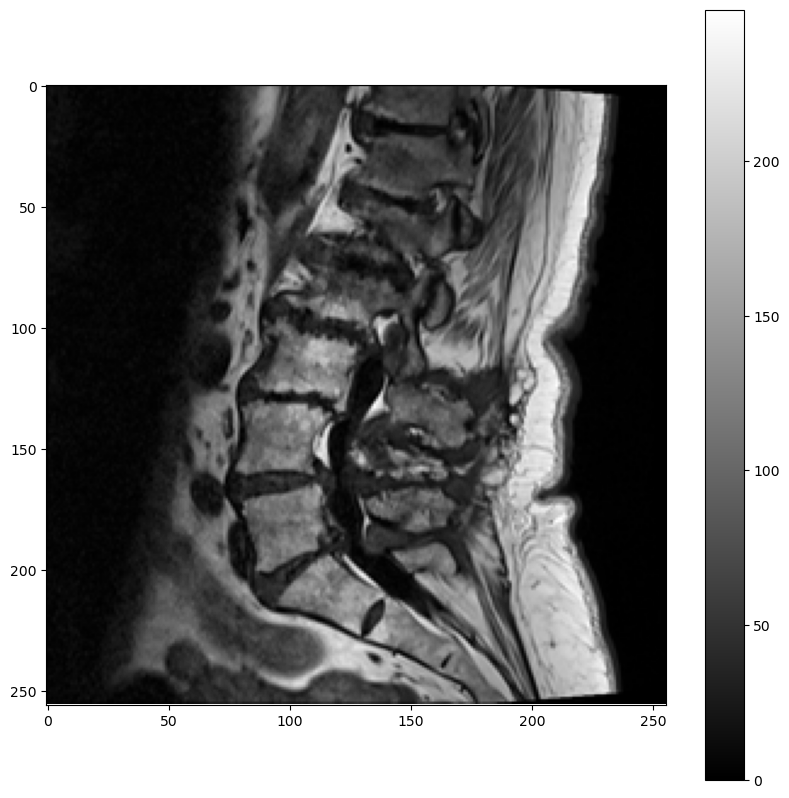

In [10]:
IMG_SIZE = (256, 256)
eps=1e-12

def dicomToArray(path):
    dicom = pydicom.read_file(path)
    data = pydicom.pixel_data_handlers.util.apply_modality_lut(dicom.pixel_array, dicom)
    data = pydicom.pixel_data_handlers.util.apply_windowing(data, dicom)
    # data = dicom.pixel_array
    if dicom.PhotometricInterpretation == "MONOCHROME1":
        data = np.amax(data) - data
        
    w, h = data.shape[0], data.shape[1]

    #Center crop
    if w>h:
        diff = w-h
        data = data[diff//2:diff//2+h, :]
    if h>w:
        diff = h-w
        data = data[:, diff//2:diff//2+w]

    data = data - np.min(data)
    data = data * 1.0/(np.max(data)+eps)

    w, h = data.shape[0], data.shape[1]

    # resize
    if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
        data = np.array(Image.fromarray((data * 255).astype(np.uint8), mode="L").resize(IMG_SIZE))

    # data = (data * 255).astype(np.uint8)
    return data


plt.figure(figsize=(10,10))
_ = plt.imshow(dicomToArray(os.path.join(DATA_PATH, "test_images/44036939/2828203845/15.dcm")), cmap="gray")
_ = plt.colorbar()

# plt.figure(figsize=(10,10))
# for i,filePath in enumerate(np.random.choice(allFiles, 9)):
#     plt.subplot(3,3, i+1)
#     _ = plt.imshow(dicomToArray(filePath), cmap="gray")
#     _ = plt.axis("off")
# plt.colorbar()

## Dataset

In [11]:
if os.path.exists(os.path.join(DATA_PATH,"./dataCC.pkl")):
    with open(os.path.join(DATA_PATH,"./dataCC.pkl"), "rb") as f:
        dictData = pickle.load(f)
        X,y = dictData["X"], dictData["y"],
else:
    X=[]
    y=[]
    for i,filePath in enumerate(tqdm(mappedLabels.keys())):
        label = mappedLabels[filePath]
        im = dicomToArray(os.path.join(DATA_PATH, filePath))
     
        X.append(im)
        y.append(label)

        #TODO: Include some non-pathological slices? (label [0,0,0,...,0])
            
    with open(os.path.join(DATA_PATH,"./dataCC.pkl"), "wb") as f:
        pickle.dump({"X":X, "y":y}, f)

print(len(X))
print(X[0].shape)
print(y[0])

24546
(256, 256)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [12]:
from torchvision.transforms import v2

transforms = v2.Compose([
    # v2.RandomHorizontalFlip(p=0.5),
    # v2.RandomVerticalFlip(p=0.5),
    v2.Grayscale(3),
    # v2.RandomResizedCrop(IMG_SIZE, (0.2,0.6), (0.8,1.2)),
    v2.Resize(IMG_SIZE),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transformsVal = v2.Compose([
    v2.Grayscale(3),
    v2.Resize(IMG_SIZE),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

TRAIN_TEST_SPLIT = 0.7

import random
random.seed(186)

split = int(len(X)*TRAIN_TEST_SPLIT)
print("# Training samples:",split)
dataShuffled = list(zip(X,y))
random.shuffle(dataShuffled)

trainData = dataShuffled[0:split]
valData = dataShuffled[split::]

# trainData = trainData[0:300]
# valData = valData[0:300]

def generator():
    for im, label in trainData:
        im = np.expand_dims(im,0)
        im = im.astype(np.float32)/255.0
        im = transforms(torch.Tensor(im))
        yield im, np.array(label).astype(np.int64)


def generatorVal():
    for imVal, labelVal in valData:
        imVal = np.expand_dims(imVal,0)
        imVal = imVal.astype(np.float32)/255.0
        imVal = transformsVal(torch.Tensor(imVal))
        yield imVal, np.array(labelVal).astype(np.int64)

# def generatorAll():
#     for id in allIds:
#         yield getData(id)

# Training samples: 17182


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


tensor(-2.1179) tensor(2.5703)
torch.Size([3, 256, 256])
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


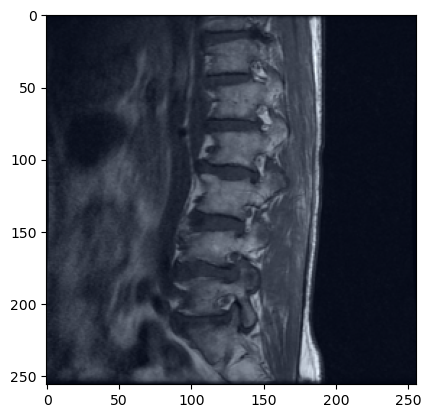

In [13]:
g = generator()
gVal = generatorVal()
testInstance = next(g)
testInstanceVal = next(gVal)

plt.imshow((torch.moveaxis(testInstance[0], 0,-1)*0.225)+0.485)
print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])

In [14]:
BATCH_SIZE = 16

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(trainData))
datasetVal = IterDataset(generatorVal, len(valData))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [15]:
for XData, targets in trainLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {XData.shape} {XData.dtype}")
    print("Max and Min: ", torch.max(XData), torch.min(XData))
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    break

Shape of X: torch.Size([16, 3, 256, 256]) torch.float32
Max and Min:  tensor(2.6400) tensor(-2.1179)
Shape of target: torch.Size([16, 25]) torch.int64


In [16]:
idx=4
print(targets[idx])
# plt.figure(figsize=(12,12))
# plt.imshow(XData[idx,:,:,:])
# _=plt.axis("off")

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 1, 0, 0, 0, 0, 0,
        0])


## Model

In [17]:
testF = torch.nn.CrossEntropyLoss()
# 8 Instances and 3 classes (0,1,2)
targetsTest = torch.Tensor([[0,2,0,1,0,2,0,1]]).type(torch.LongTensor) 
predsTest = torch.randn((1,3,8)).type(torch.float64)
print(predsTest)
testF(predsTest, targetsTest)

tensor([[[-1.2970, -0.5765, -0.9670, -0.2809,  0.8561, -0.3367,  0.4554,
           1.2356],
         [ 0.8641,  0.3210, -0.0984,  1.3497,  0.3064, -0.6641, -0.0236,
           1.8862],
         [-0.9555, -0.8277, -0.1715, -0.8230, -0.7030,  1.0654,  1.0192,
          -0.0768]]], dtype=torch.float64)


tensor(1.0938, dtype=torch.float64)

In [18]:
import torchinfo


# model = timm.create_model('edgenext_base', pretrained=True, num_classes=len(allLabels)*len(labelMapping))
# model.name = f"edgenext_base_{IMG_SIZE[0]}"

# model = timm.create_model('resnet34d', pretrained=True, num_classes=len(enc.classes_))
# model.name = "resnet34d_384_wang"

# model = timm.create_model('rexnet_150', pretrained=True, num_classes=len(enc.classes_))
# model.name = "RexNet150"

class EdgeNext(torch.nn.Module):
    def __init__(self):
        super(EdgeNext, self).__init__()
        self.name="PathClassifierEdgeNext"

        self.basemodel = timm.create_model('edgenext_base', pretrained=True, num_classes=len(allLabels)*len(labelMapping))
        # self.basemodel = timm.create_model('edgenext_base', pretrained=True, num_classes=0)
        self.flatten = torch.nn.Flatten()
        self.linear2 = torch.nn.Linear(37376, len(allLabels)*len(labelMapping))
        # self.softmax = torch.nn.Softmax(dim=1)

    def forward(self, x):
        x = self.basemodel(x)
        # x = self.basemodel.forward_features(x)
        # x = self.flatten(x)
        # x = self.linear2(x)
        x = torch.reshape(x, (x.shape[0], len(labelMapping), len(allLabels)))
        # x = self.softmax(x)
        return x

model = EdgeNext()

from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)
model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

Layer (type:depth-idx)                                            Output Shape              Param #
EdgeNext                                                          [16, 3, 25]               2,803,275
├─EdgeNeXt: 1-1                                                   [16, 75]                  --
│    └─Sequential: 2-1                                            [16, 80, 64, 64]          --
│    │    └─Conv2d: 3-1                                           [16, 80, 64, 64]          3,920
│    │    └─LayerNorm2d: 3-2                                      [16, 80, 64, 64]          160
│    └─Sequential: 2-2                                            [16, 584, 8, 8]           --
│    │    └─EdgeNeXtStage: 3-3                                    [16, 80, 64, 64]          157,920
│    │    └─EdgeNeXtStage: 3-4                                    [16, 160, 32, 32]         792,808
│    │    └─EdgeNeXtStage: 3-5                                    [16, 288, 16, 16]         6,628,552
│    │    └─EdgeN

In [19]:
loadExistingModel=False

if loadExistingModel:
    model = model.to(device)
    checkpoint = torch.load(os.path.join("./", "edgenextBase_384_epoch_8.pt"), map_location=device)
    print(model.load_state_dict(checkpoint['model_state_dict']))
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, steps_per_epoch=len(trainLoader), epochs=10)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.01)/100))
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    startEpoch = checkpoint['epoch']
    # startEpoch=0
    # loss = checkpoint['loss']
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(trainLoader), epochs=15)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.1)/500))

Epoch 1
-------------------------------
loss: 1.102871, Acc: 0.3046, F1: 0.2051  [   16/17182]
loss: 0.367259, Acc: 0.3351, F1: 0.3248  [  112/17182]
loss: 0.246095, Acc: 0.3343, F1: 0.3299  [  208/17182]
loss: 0.155814, Acc: 0.3327, F1: 0.3295  [  304/17182]
loss: 0.434562, Acc: 0.3316, F1: 0.3281  [  400/17182]
loss: 0.109578, Acc: 0.3322, F1: 0.3285  [  496/17182]
loss: 0.310447, Acc: 0.3322, F1: 0.3279  [  592/17182]
loss: 0.227384, Acc: 0.3324, F1: 0.3276  [  688/17182]
loss: 0.255601, Acc: 0.3324, F1: 0.3271  [  784/17182]
loss: 0.233598, Acc: 0.3324, F1: 0.3265  [  880/17182]
loss: 0.282828, Acc: 0.3323, F1: 0.3257  [  976/17182]
loss: 0.224975, Acc: 0.3332, F1: 0.3270  [ 1072/17182]
loss: 0.213845, Acc: 0.3332, F1: 0.3269  [ 1168/17182]
loss: 0.229322, Acc: 0.3332, F1: 0.3267  [ 1264/17182]
loss: 0.211857, Acc: 0.3332, F1: 0.3265  [ 1360/17182]
loss: 0.164872, Acc: 0.3332, F1: 0.3263  [ 1456/17182]
loss: 0.351323, Acc: 0.3332, F1: 0.3261  [ 1552/17182]
loss: 0.144487, Acc: 0.33

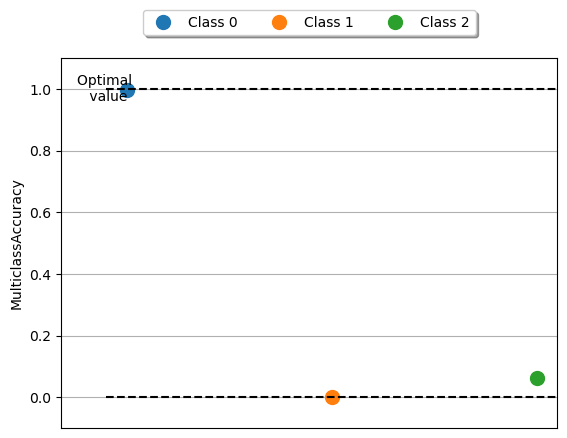

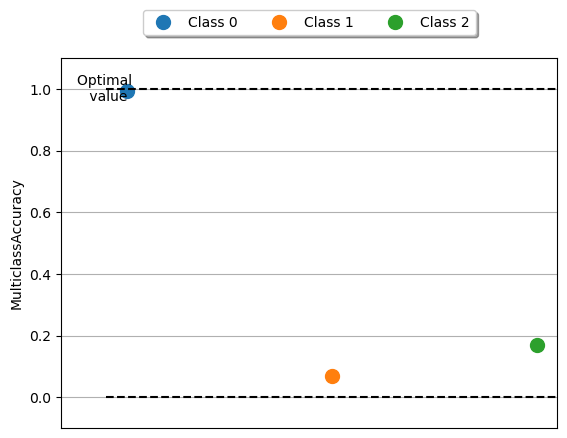

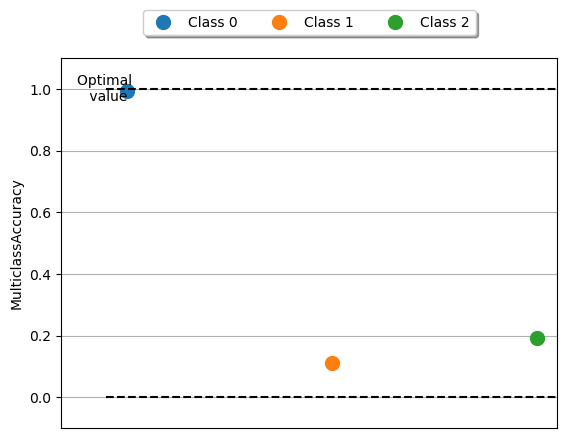

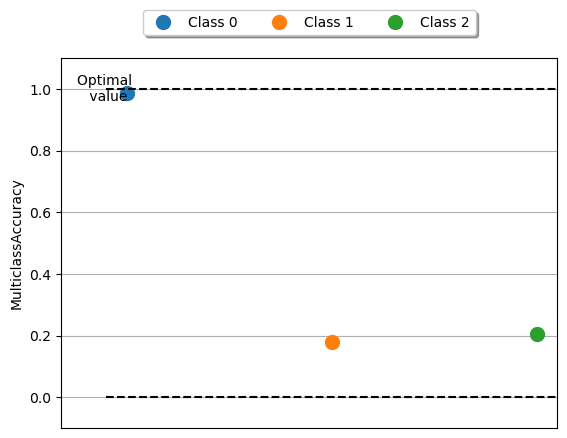

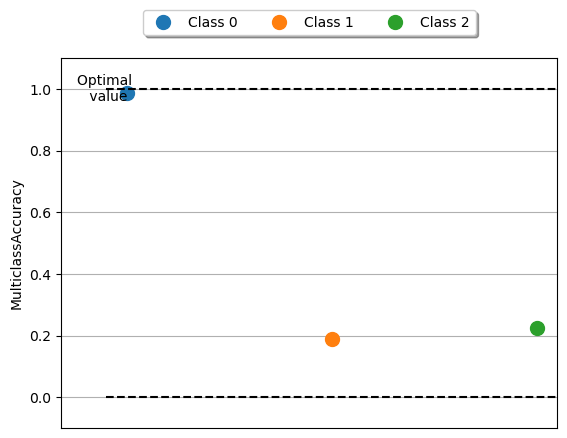

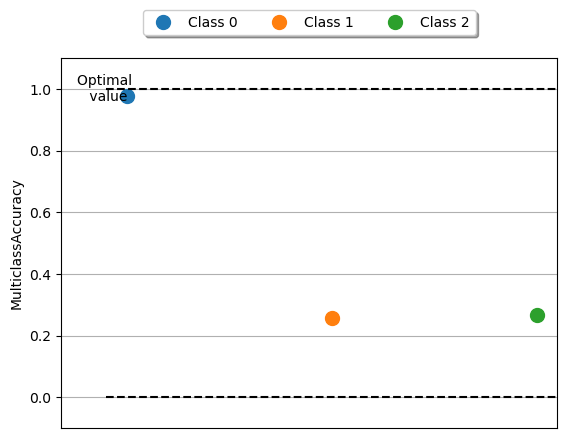

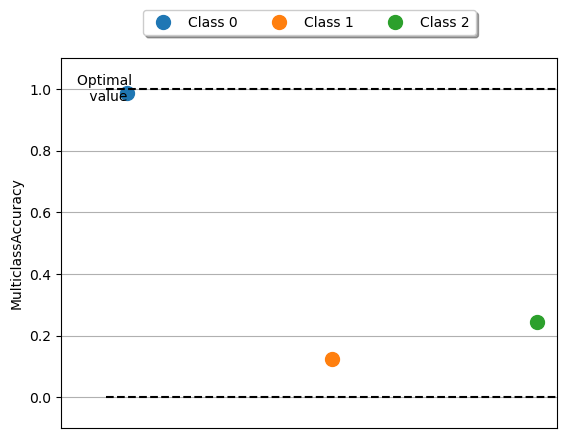

In [20]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

LOG_INTERVAL=6
epochs = 100
saveModel=False
SAVE_MODEL_INTERVAL=10
EARLY_STOPPING_PATIENCE = 3


use_amp = True

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

log_dir = "./logs/"+model.name+"/" + datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = SummaryWriter(log_dir)


# Instantiate a loss function.
# bceLoss = FocalLoss()
loss = torch.nn.CrossEntropyLoss()
lossVal = torch.nn.CrossEntropyLoss()

f1Metric = MulticlassF1Score(num_classes=len(labelMapping)).to(device)
accMetric = MulticlassAccuracy(num_classes=len(labelMapping)).to(device)

f1MetricVal = MulticlassF1Score(num_classes=len(labelMapping)).to(device)
accMetricVal = MulticlassAccuracy(num_classes=len(labelMapping), average=None).to(device)


def train(dataloader, model, lossFn, optimizer, epoch):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            # Compute prediction error
            pred = model(X)
            loss = lossFn(pred, y)
        accMetric.update(pred, y)
        f1Metric.update(pred, y)

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        if batch % LOG_INTERVAL == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}, Acc: {accMetric.compute():.4f}, F1: {f1Metric.compute():.4f}  [{current:>5d}/{size:>5d}]")
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Accuracy", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("F1", f1Metric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()

@torch.no_grad()
def validate(dataloader, model, loss_fn, epoch):
    num_batches = len(dataloader)
    model.eval()
    valLoss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            valLoss += loss_fn(pred, y).item()
            accMetricVal.update(pred, y)
            f1MetricVal.update(pred, y)

    valLoss /= num_batches
    fig_, ax_ = accMetricVal.plot()
    fig_.savefig(f"./valPlots/acc_{t}.png")
    
    print(f"Validation: Loss {valLoss:>4f}, F1 {f1MetricVal.compute():.4f}  Accuracy {torch.mean(accMetricVal.compute()):.4f} \n")
    summary_writer.add_scalar("Val Loss", valLoss, epoch)
    summary_writer.add_scalar("Val Accuracy", torch.mean(accMetricVal.compute()), epoch)
    summary_writer.add_scalar("Val F1", f1MetricVal.compute(), epoch)
    summary_writer.flush()
    return valLoss

bestPerformance=99
bestEpoch=0

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainLoader, model, loss, optimizer, t)
    valLoss=validate(valLoader, model, lossVal, t)
    # scheduler.step()
    if t%SAVE_MODEL_INTERVAL==0:
        print("LR: ", optimizer.param_groups[0]['lr'])
    if valLoss < bestPerformance:
        bestPerformance = valLoss
        print(f"New best performance: {bestPerformance:.4f}")
        bestF1=f1MetricVal.compute()
        bestEpoch=t
        bestWeights = model.state_dict()
    if t-bestEpoch>EARLY_STOPPING_PATIENCE:
        print(f"Early Stopping. {bestF1=}")
        break
    accMetric.reset()
    f1Metric.reset()
    accMetricVal.reset()
    f1MetricVal.reset()

print("Done!")

In [21]:
print(model.load_state_dict(bestWeights))

torch.save({
        'epoch': t,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # "scaler": scaler.state_dict(),
        # 'scheduler_state_dict': scheduler.state_dict(),
        # 'loss': loss,
        }, os.path.join("./", f"{model.name}_F1_{bestF1:.3f}_epoch_{bestEpoch}.pt"))

<All keys matched successfully>
